# EDA — Station VNTU (ID 1315) · PM2.5

Exploratory data analysis for the **PM2.5** parameter at **VNTU (station_id = 1315)**.

Sections:
1. Setup & connection
2. Dataset overview
3. Time coverage & data completeness
4. Descriptive statistics & distribution
5. Time-series overview
6. Rolling statistics
7. Seasonal / calendar patterns
8. Quality & data-flag analysis
9. Pollution-level distribution
10. Anomaly / out-of-bounds audit
11. Correlation with other parameters at the same station
12. Key findings


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sqlalchemy import create_engine, text, URL

# ── Plotting style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

PALETTE = {
    'primary': '#2C7BB6',
    'accent':  '#D7191C',
    'ok':      '#1A9641',
    'warn':    '#FDAE61',
    'muted':   '#7F7F7F',
    'bg':      '#FAFAFA',
}

print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Setup & connection

In [2]:
DB_USER     = os.getenv('MYSQL_USER')
DB_PASSWORD = os.getenv('MYSQL_PASSWORD')
DB_HOST     = os.getenv('DB_HOST')
DB_PORT     = int(os.getenv('DB_PORT', 3306))
DB_NAME     = os.getenv('MYSQL_DATABASE')

engine = create_engine(
    URL.create(
        'mysql',
        DB_USER,
        DB_PASSWORD,
        DB_HOST,
        DB_PORT,
        DB_NAME,
    ),
    pool_pre_ping=True,
)

with engine.connect() as c:
    print('DB connection OK:', c.execute(text('SELECT VERSION()')).scalar())

DB connection OK: 8.0.42


## 2 · Resolve keys & fetch data

In [3]:
STATION_ID  = 1315  # VNTU (station_id in dim_stations; station_key=6)
PM25_CODES  = ('PM2.5', 'SDSP2', 'PMSP2')

# Resolve dimension keys
KEY_QUERY = text("""
    SELECT
        ds.station_key,
        ds.station_name,
        ds.latitude,
        ds.longitude,
        dp.parameter_key,
        dp.parameter_code,
        dp.physical_min,
        dp.physical_max,
        dp.gdk_daily,
        dp.gdk_short_term,
        dp.gdk_unit_basis,
        du.unit_symbol
    FROM   dim_stations   ds
    JOIN   dim_parameters dp ON dp.is_current = 1
                              AND dp.parameter_code IN :codes
    LEFT   JOIN dim_units du ON du.unit_key = dp.unit_key
    WHERE  ds.station_id  = :sid
      AND  ds.is_current  = 1
""")

with engine.connect() as c:
    meta_df = pd.read_sql(
        KEY_QUERY,
        c,
        params={'sid': STATION_ID, 'codes': PM25_CODES},
    )

display(meta_df)

station_key   = int(meta_df['station_key'].iloc[0])
station_name  = meta_df['station_name'].iloc[0]
parameter_keys = meta_df['parameter_key'].tolist()
unit_symbol   = meta_df['unit_symbol'].iloc[0] or 'µg/m³'
physical_min  = float(meta_df['physical_min'].iloc[0]) if meta_df['physical_min'].iloc[0] is not None else 0.0
physical_max  = float(meta_df['physical_max'].iloc[0]) if meta_df['physical_max'].iloc[0] is not None else 500.0
gdk_daily     = float(meta_df['gdk_daily'].iloc[0])     if meta_df['gdk_daily'].iloc[0]     is not None else None
gdk_short     = float(meta_df['gdk_short_term'].iloc[0]) if meta_df['gdk_short_term'].iloc[0] is not None else None

pk_csv = ', '.join(str(k) for k in parameter_keys)
print(f'\nStation key : {station_key}  ({station_name})')
print(f'Parameter keys : {pk_csv}')
print(f'Physical range : [{physical_min}, {physical_max}] {unit_symbol}')
print(f'GDK daily      : {gdk_daily}')
print(f'GDK short-term : {gdk_short}')

,station_key,station_name,latitude,longitude,parameter_key,parameter_code,physical_min,physical_max,gdk_daily,gdk_short_term,gdk_unit_basis,unit_symbol
0,6,Vinnytsia National Technical University,49.2333,28.4092,1,SDSP2,0.0,500.0,25.0,35.0,24h_avg,µg/m³
1,6,Vinnytsia National Technical University,49.2333,28.4092,8,PM2.5,0.0,500.0,25.0,35.0,24h_avg,µg/m³
2,6,Vinnytsia National Technical University,49.2333,28.4092,13,PMSP2,0.0,500.0,25.0,35.0,24h_avg,µg/m³



Station key : 6  (Vinnytsia National Technical University)
Parameter keys : 1, 8, 13
Physical range : [0.0, 500.0] µg/m³
GDK daily      : 25.0
GDK short-term : 35.0


In [4]:
# Fetch full PM2.5 time-series for the station
# Chunked read so MySQL doesn't time out on 7 M rows.
# We pull only the columns we need.

TS_QUERY = f"""
    SELECT
        measurement_id,
        measurement_timestamp,
        value,
        quality_ratio,
        pollution_level
    FROM   fact_measurements
    WHERE  station_key   = {station_key}
      AND  parameter_key IN ({pk_csv})
    ORDER  BY measurement_timestamp
"""

with engine.connect() as c:
    df = pd.read_sql(text(TS_QUERY), c, parse_dates=['measurement_timestamp'])

df.rename(columns={'measurement_timestamp': 'ts', 'value': 'pm25'}, inplace=True)
df.set_index('ts', inplace=True)
df.sort_index(inplace=True)

print(f'Rows fetched : {len(df):,}')
print(f'Date range   : {df.index.min()}  →  {df.index.max()}')
df.head()

Rows fetched : 41,723
Date range   : 2022-12-06 10:33:05  →  2026-04-27 00:39:32


,measurement_id,pm25,quality_ratio,pollution_level
ts,,,,
2022-12-06 10:33:05,190384,26.0,1.0,4.0
2022-12-06 10:34:07,190422,26.0,1.0,4.0
2022-12-06 10:39:19,190460,23.0,1.0,3.0
2022-12-06 10:44:31,190498,27.0,1.0,4.0
2022-12-06 10:49:43,190536,31.0,1.0,4.0


## 3 · Dataset overview & completeness

In [5]:
# Overview stats
n_total   = len(df)
n_null    = df['pm25'].isna().sum()
n_valid   = n_total - n_null
n_oob     = ((df['pm25'] < physical_min) | (df['pm25'] > physical_max)).sum()
n_in_range = n_valid - n_oob

date_span = (df.index.max() - df.index.min()).days
days_with_data = df.resample('D')['pm25'].count().gt(0).sum()
completeness = days_with_data / date_span * 100

print('─' * 50)
print(f'  Total rows          : {n_total:>10,}')
print(f'  NULL values         : {n_null:>10,}  ({n_null/n_total*100:.1f}%)')
print(f'  Valid (non-NULL)    : {n_valid:>10,}  ({n_valid/n_total*100:.1f}%)')
print(f'  Out-of-bounds       : {n_oob:>10,}  ({n_oob/n_valid*100:.2f}% of valid)')
print(f'  In-range            : {n_in_range:>10,}  ({n_in_range/n_total*100:.1f}%)')
print(f'  Date span           : {date_span} days')
print(f'  Days with data      : {days_with_data}')
print(f'  Day-level completeness: {completeness:.1f}%')
print('─' * 50)

──────────────────────────────────────────────────
  Total rows          :     41,723
  NULL values         :          0  (0.0%)
  Valid (non-NULL)    :     41,723  (100.0%)
  Out-of-bounds       :          0  (0.00% of valid)
  In-range            :     41,723  (100.0%)
  Date span           : 1237 days
  Days with data      : 633
  Day-level completeness: 51.2%
──────────────────────────────────────────────────


Estimated interval: ~20.0 min  → expected ~72 readings/day


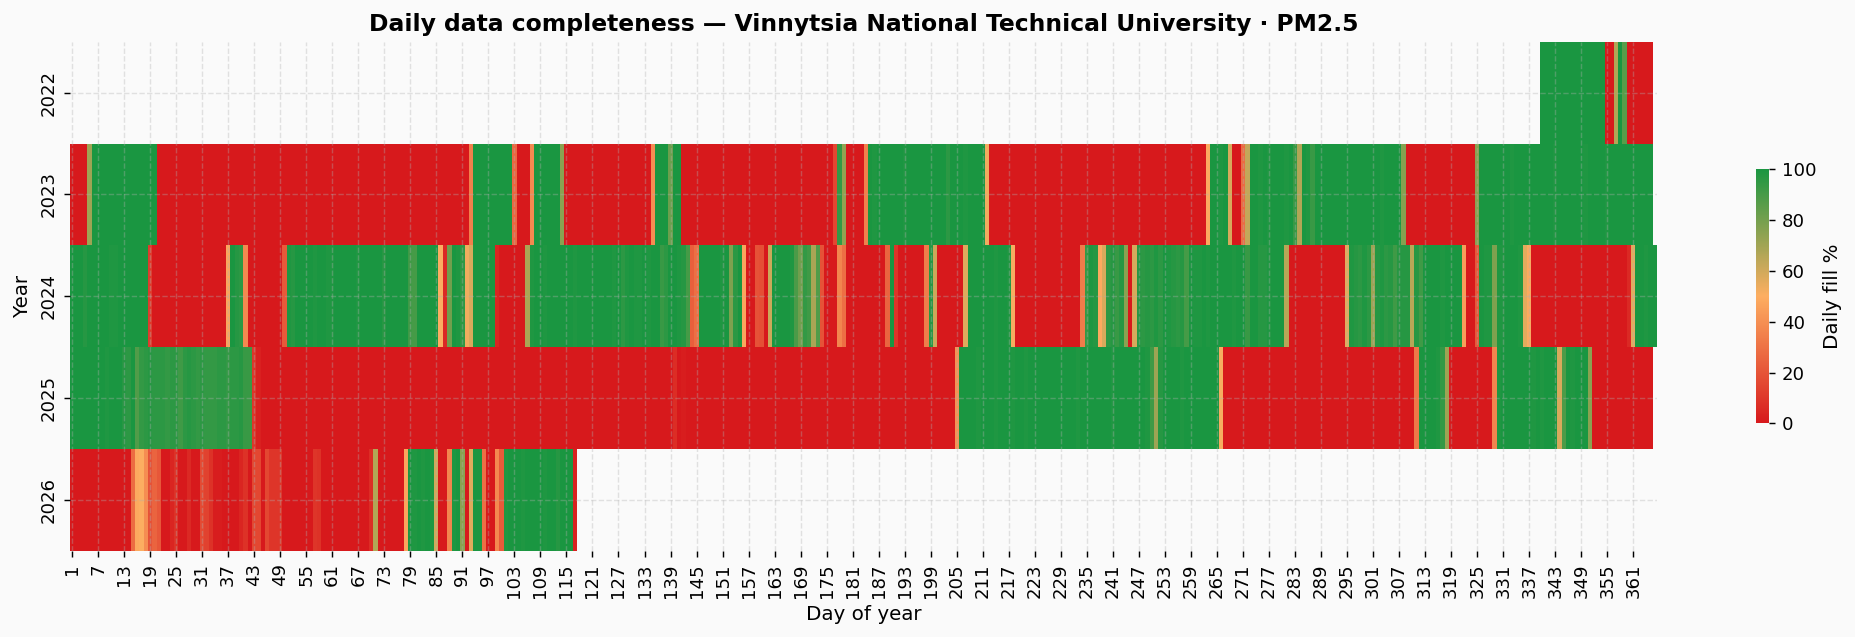

In [6]:
daily_counts = df['pm25'].resample('D').count().rename('count').to_frame()
daily_counts['year']  = daily_counts.index.year
daily_counts['month'] = daily_counts.index.month
daily_counts['day']   = daily_counts.index.day

# Expected readings/day = 24*60/sensor_interval; estimate from median gap
ts_diff = df.index.to_series().diff().dt.total_seconds().dropna()
median_interval_min = ts_diff[ts_diff > 0].median() / 60
expected_per_day = max(1, round(1440 / median_interval_min))
print(f'Estimated interval: ~{median_interval_min:.1f} min  → expected ~{expected_per_day} readings/day')

daily_counts['fill_pct'] = (daily_counts['count'] / expected_per_day * 100).clip(0, 100)

# Pivot to year × day-of-year for heatmap
daily_counts['doy'] = daily_counts.index.day_of_year
pivot = daily_counts.pivot_table(index='year', columns='doy', values='fill_pct')

cmap = LinearSegmentedColormap.from_list('completeness', ['#D7191C', '#FDAE61', '#1A9641'])

fig, ax = plt.subplots(figsize=(16, max(2, len(pivot) * 0.7 + 1.5)))
sns.heatmap(
    pivot, ax=ax, cmap=cmap, vmin=0, vmax=100,
    linewidths=0, cbar_kws={'label': 'Daily fill %', 'shrink': 0.5}
)
ax.set_title(f'Daily data completeness — {station_name} · PM2.5')
ax.set_xlabel('Day of year')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

In [8]:
# Identify groups of consecutive NaNs
gap_groups = null_mask.cumsum()

# Use agg instead of apply for better performance and explicit naming
gaps = (
    df[null_mask]
    .groupby(gap_ids[null_mask])
    .agg(
        start=('pm25', lambda _: _.index[0]),
        end=('pm25', lambda _: _.index[-1]),
        n=('pm25', 'size')
    )
    .reset_index(drop=True)
)

# Only sort if there is actually data to sort
if not gaps.empty:
    gaps = gaps.sort_values('n', ascending=False)

NameError: name 'null_mask' is not defined

## 4 · Descriptive statistics & distribution

In [9]:
valid = df['pm25'].dropna()
inrange = valid[(valid >= physical_min) & (valid <= physical_max)]

desc = inrange.describe(percentiles=[.01,.05,.25,.5,.75,.90,.95,.99,.999])
print('── Descriptive statistics (in-range values) ──────────────────')
print(desc.to_string())
print(f'\nSkewness : {stats.skew(inrange):.3f}')
print(f'Kurtosis : {stats.kurtosis(inrange):.3f}')
if gdk_daily:
    exc_pct = (inrange > gdk_daily).sum() / len(inrange) * 100
    print(f'\nExceed GDK daily ({gdk_daily} {unit_symbol}): {exc_pct:.1f}% of readings')
if gdk_short:
    exc_pct2 = (inrange > gdk_short).sum() / len(inrange) * 100
    print(f'Exceed GDK short-term ({gdk_short} {unit_symbol}): {exc_pct2:.1f}% of readings')

── Descriptive statistics (in-range values) ──────────────────
count    41723.000000
mean        24.002388
std         11.218178
min          0.000000
1%           5.811358
5%          10.531480
25%         17.000000
50%         21.240000
75%         28.544700
90%         38.229380
95%         44.582590
99%         62.635542
99.9%       99.671152
max        225.481000

Skewness : 2.072
Kurtosis : 10.435

Exceed GDK daily (25.0 µg/m³): 34.5% of readings
Exceed GDK short-term (35.0 µg/m³): 13.6% of readings


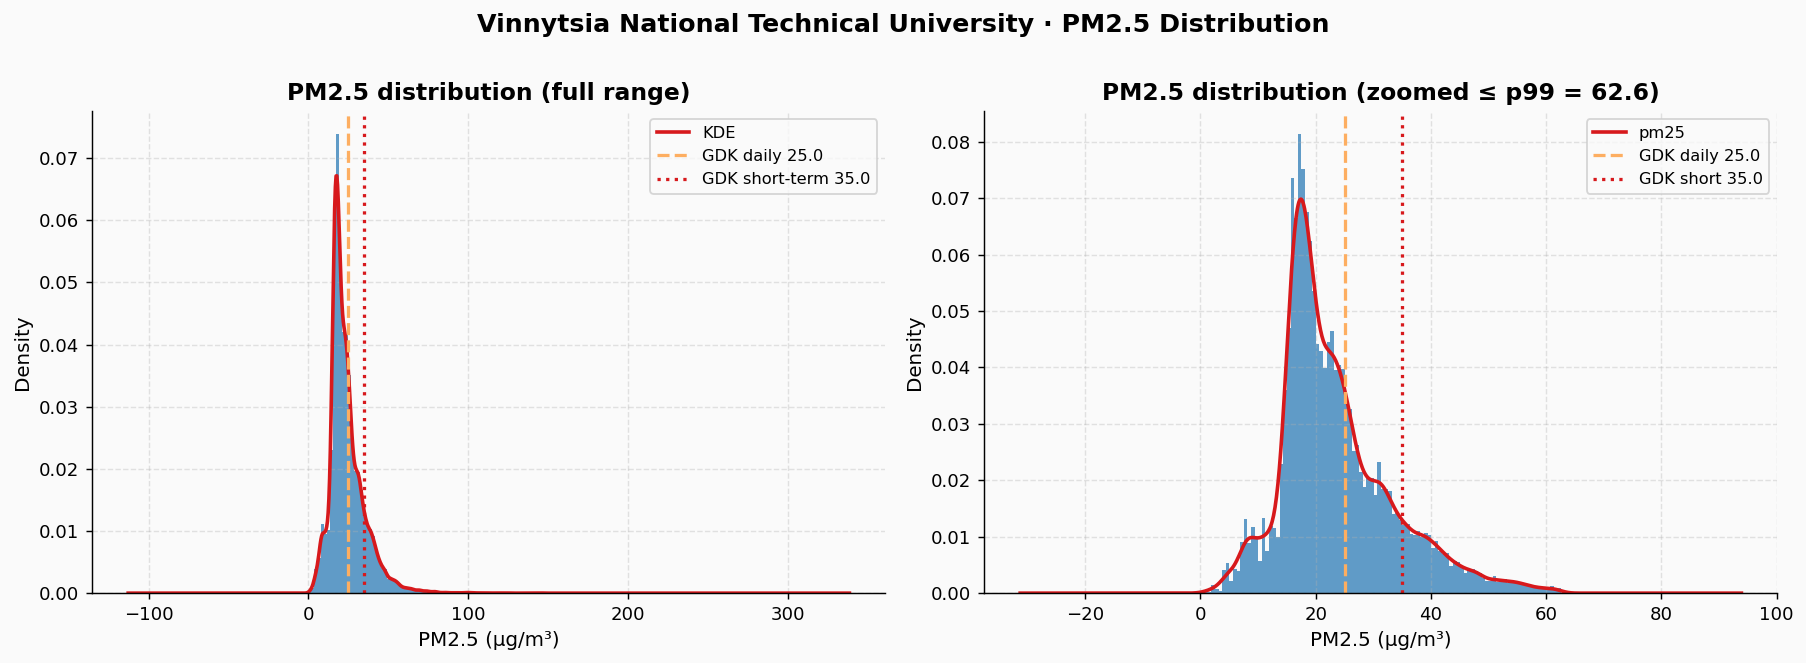

In [10]:
# ── Distribution: histogram + KDE + reference lines ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full range histogram
ax = axes[0]
ax.hist(inrange, bins=120, color=PALETTE['primary'], alpha=0.75, edgecolor='none', density=True)
inrange.plot.kde(ax=ax, color=PALETTE['accent'], linewidth=2, label='KDE')
if gdk_daily:
    ax.axvline(gdk_daily,  color=PALETTE['warn'],   lw=1.8, ls='--', label=f'GDK daily {gdk_daily}')
if gdk_short:
    ax.axvline(gdk_short, color=PALETTE['accent'], lw=1.8, ls=':',  label=f'GDK short-term {gdk_short}')
ax.set_title('PM2.5 distribution (full range)')
ax.set_xlabel(f'PM2.5 ({unit_symbol})')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

# Right: zoomed to p99 for readability
ax2 = axes[1]
p99 = inrange.quantile(0.99)
clipped = inrange[inrange <= p99]
ax2.hist(clipped, bins=100, color=PALETTE['primary'], alpha=0.75, edgecolor='none', density=True)
clipped.plot.kde(ax=ax2, color=PALETTE['accent'], linewidth=2)
if gdk_daily and gdk_daily <= p99:
    ax2.axvline(gdk_daily,  color=PALETTE['warn'],   lw=1.8, ls='--', label=f'GDK daily {gdk_daily}')
if gdk_short and gdk_short <= p99:
    ax2.axvline(gdk_short, color=PALETTE['accent'], lw=1.8, ls=':',  label=f'GDK short {gdk_short}')
ax2.set_title(f'PM2.5 distribution (zoomed ≤ p99 = {p99:.1f})')
ax2.set_xlabel(f'PM2.5 ({unit_symbol})')
ax2.set_ylabel('Density')
ax2.legend(fontsize=9)

fig.suptitle(f'{station_name} · PM2.5 Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

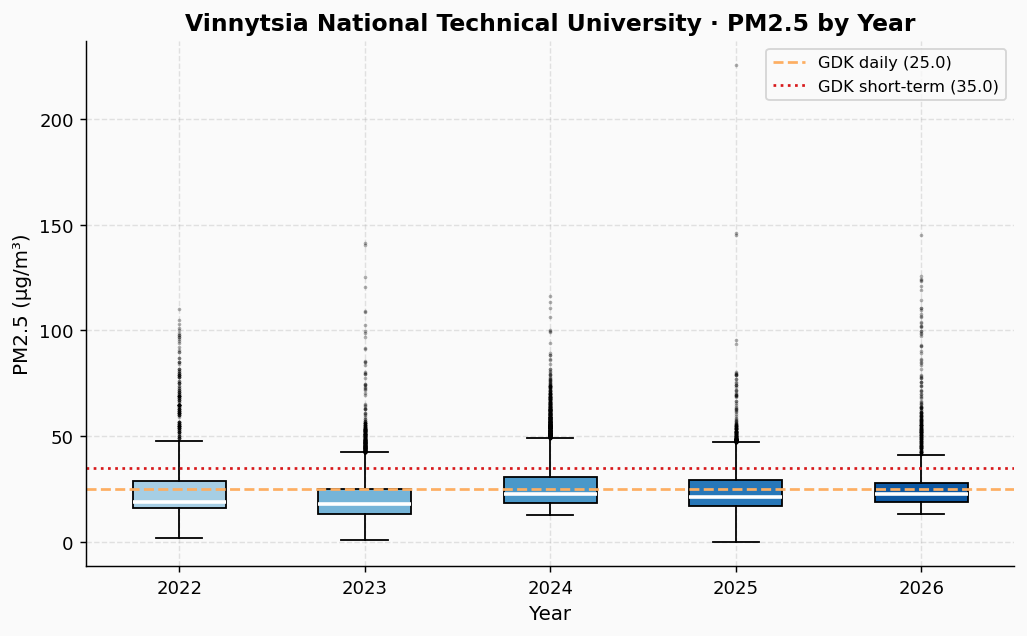

In [11]:
# ── Box-plot by year ────────────────────────────────────────────────────────
df_plot = df[['pm25']].copy()
df_plot = df_plot[(df_plot['pm25'] >= physical_min) & (df_plot['pm25'] <= physical_max)]
df_plot['year'] = df_plot.index.year

years = sorted(df_plot['year'].unique())
data_by_year = [df_plot.loc[df_plot['year'] == y, 'pm25'].dropna().values for y in years]

fig, ax = plt.subplots(figsize=(max(8, len(years)*1.4), 5))
bp = ax.boxplot(
    data_by_year, labels=years,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
)
colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(years)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

if gdk_daily:
    ax.axhline(gdk_daily, color=PALETTE['warn'],   lw=1.5, ls='--', label=f'GDK daily ({gdk_daily})')
if gdk_short:
    ax.axhline(gdk_short, color=PALETTE['accent'], lw=1.5, ls=':',  label=f'GDK short-term ({gdk_short})')

ax.set_title(f'{station_name} · PM2.5 by Year')
ax.set_xlabel('Year')
ax.set_ylabel(f'PM2.5 ({unit_symbol})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5 · Time-series overview

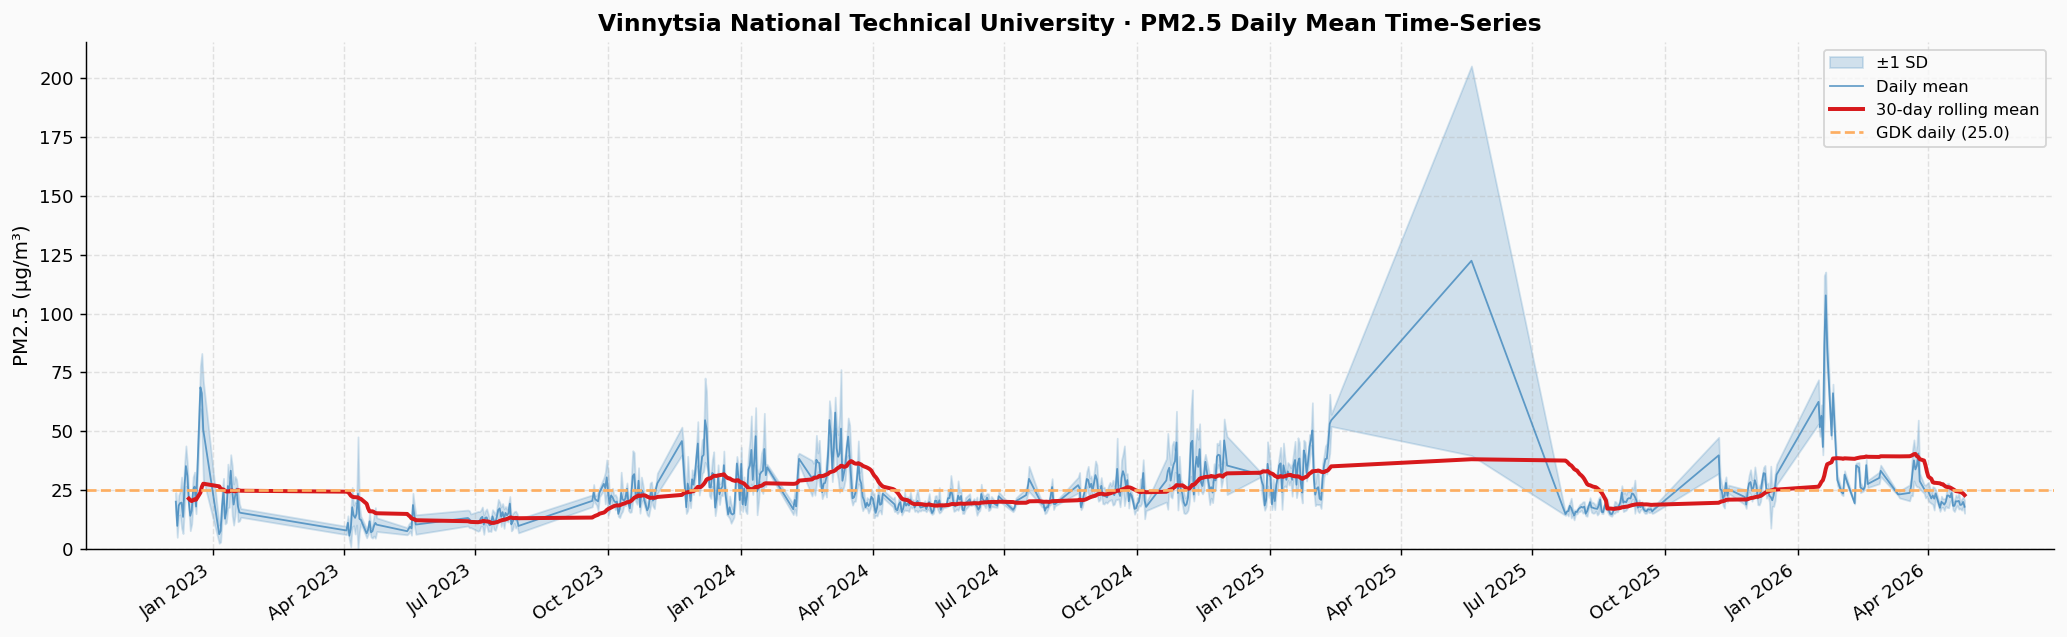

In [12]:
# ── Daily mean + ±1 SD ribbon ──────────────────────────────────────────────
daily = (
    df['pm25']
    .resample('D')
    .agg(['mean', 'std', 'max', 'min', 'count'])
    .rename(columns={'mean': 'mean', 'std': 'std', 'max': 'max', 'min': 'min', 'count': 'n'})
)
daily = daily[daily['n'] >= 3]  # skip days with very few readings

fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(
    daily.index,
    (daily['mean'] - daily['std']).clip(lower=0),
    daily['mean'] + daily['std'],
    alpha=0.2, color=PALETTE['primary'], label='±1 SD'
)
ax.plot(daily.index, daily['mean'], color=PALETTE['primary'], lw=1.0, alpha=0.7, label='Daily mean')

# 30-day rolling mean overlay
roll = daily['mean'].rolling(30, min_periods=10).mean()
ax.plot(roll.index, roll, color=PALETTE['accent'], lw=2.2, label='30-day rolling mean')

if gdk_daily:
    ax.axhline(gdk_daily, color=PALETTE['warn'], lw=1.5, ls='--', label=f'GDK daily ({gdk_daily})')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
ax.set_title(f'{station_name} · PM2.5 Daily Mean Time-Series')
ax.set_ylabel(f'PM2.5 ({unit_symbol})')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

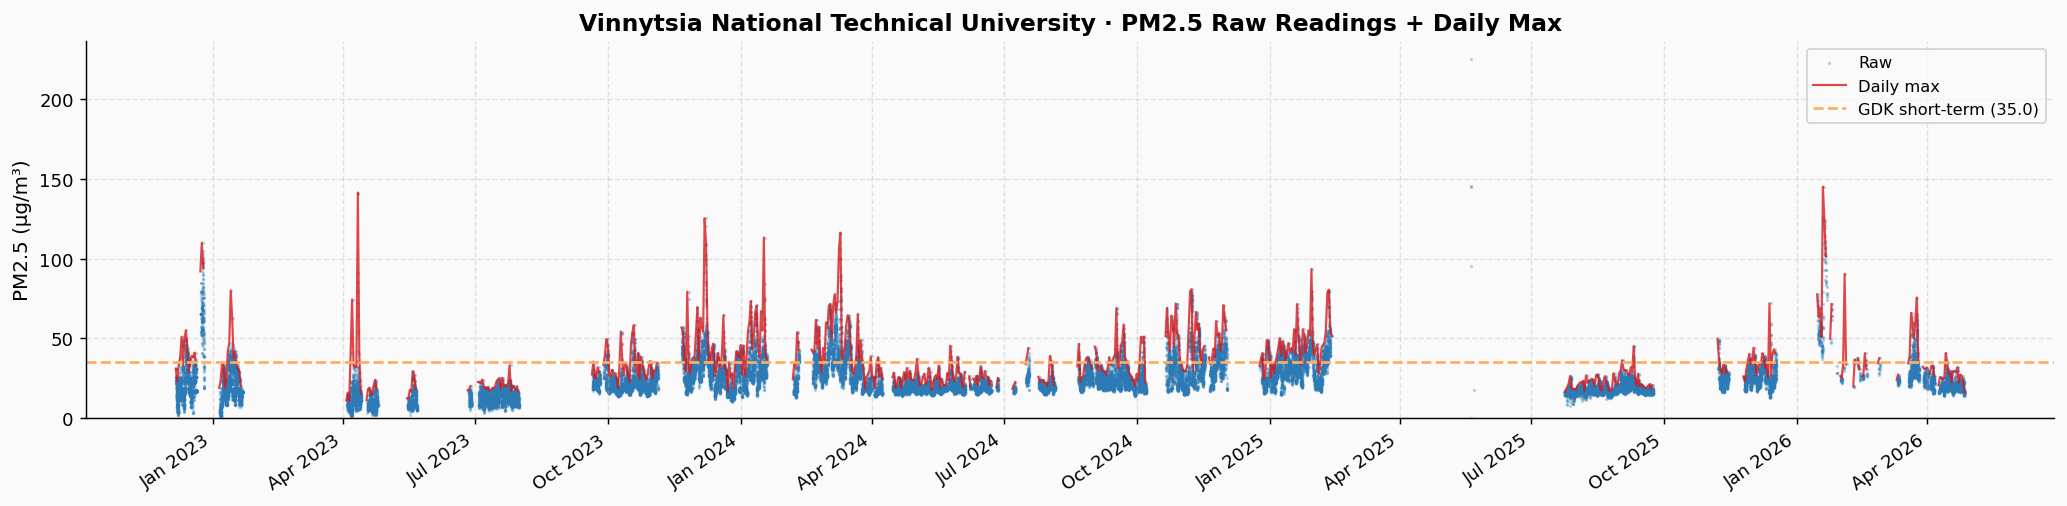

In [13]:
# ── Hourly raw scatter (thin) + daily max line ─────────────────────────────
in_range = df.loc[
    df['pm25'].between(physical_min, physical_max),
    'pm25'
]

fig, ax = plt.subplots(figsize=(16, 4))

ax.scatter(in_range.index, in_range, s=0.8, alpha=0.25, color=PALETTE['primary'], rasterized=True, label='Raw')

daily_max = in_range.resample('D').max()
ax.plot(daily_max.index, daily_max, color=PALETTE['accent'], lw=1.2, alpha=0.8, label='Daily max')

if gdk_short:
    ax.axhline(gdk_short, color=PALETTE['warn'], lw=1.5, ls='--', label=f'GDK short-term ({gdk_short})')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
ax.set_title(f'{station_name} · PM2.5 Raw Readings + Daily Max')
ax.set_ylabel(f'PM2.5 ({unit_symbol})')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6 · Rolling statistics

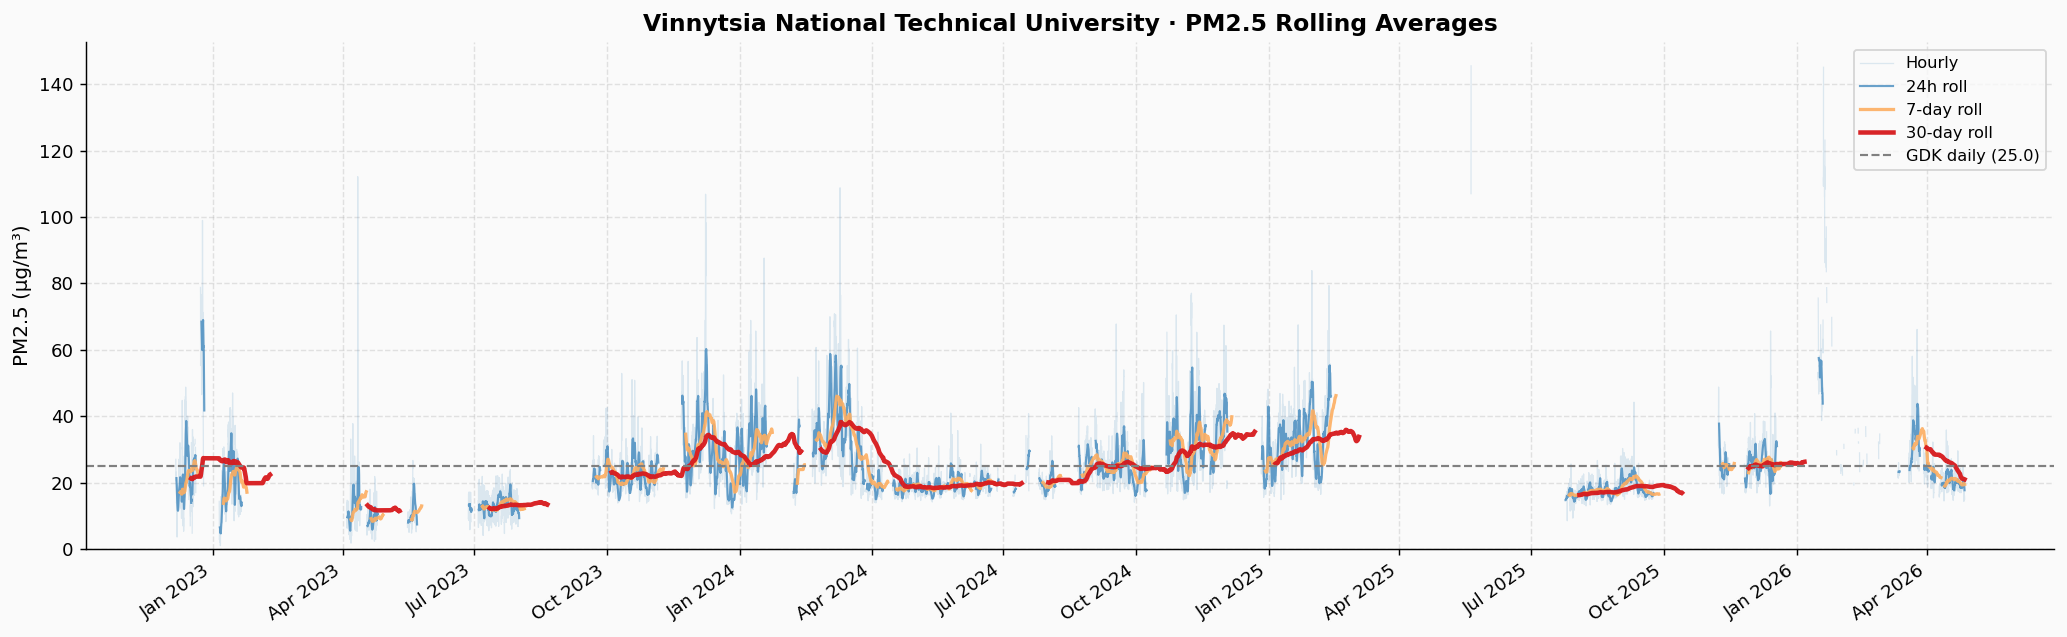

In [14]:
# ── Multi-window rolling mean ──────────────────────────────────────────────
hourly = df['pm25'].resample('h').mean()
r24h  = hourly.rolling(24,   min_periods=12).mean()
r7d   = hourly.rolling(168,  min_periods=72).mean()
r30d  = hourly.rolling(720,  min_periods=240).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(hourly.index, hourly, color=PALETTE['primary'],  alpha=0.15, lw=0.7, label='Hourly')
ax.plot(r24h.index,  r24h,   color=PALETTE['primary'],  alpha=0.7,  lw=1.2, label='24h roll')
ax.plot(r7d.index,   r7d,    color=PALETTE['warn'],      alpha=0.9,  lw=1.8, label='7-day roll')
ax.plot(r30d.index,  r30d,   color=PALETTE['accent'],    alpha=0.95, lw=2.5, label='30-day roll')

if gdk_daily:
    ax.axhline(gdk_daily, color='grey', lw=1.2, ls='--', label=f'GDK daily ({gdk_daily})')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
ax.set_title(f'{station_name} · PM2.5 Rolling Averages')
ax.set_ylabel(f'PM2.5 ({unit_symbol})')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

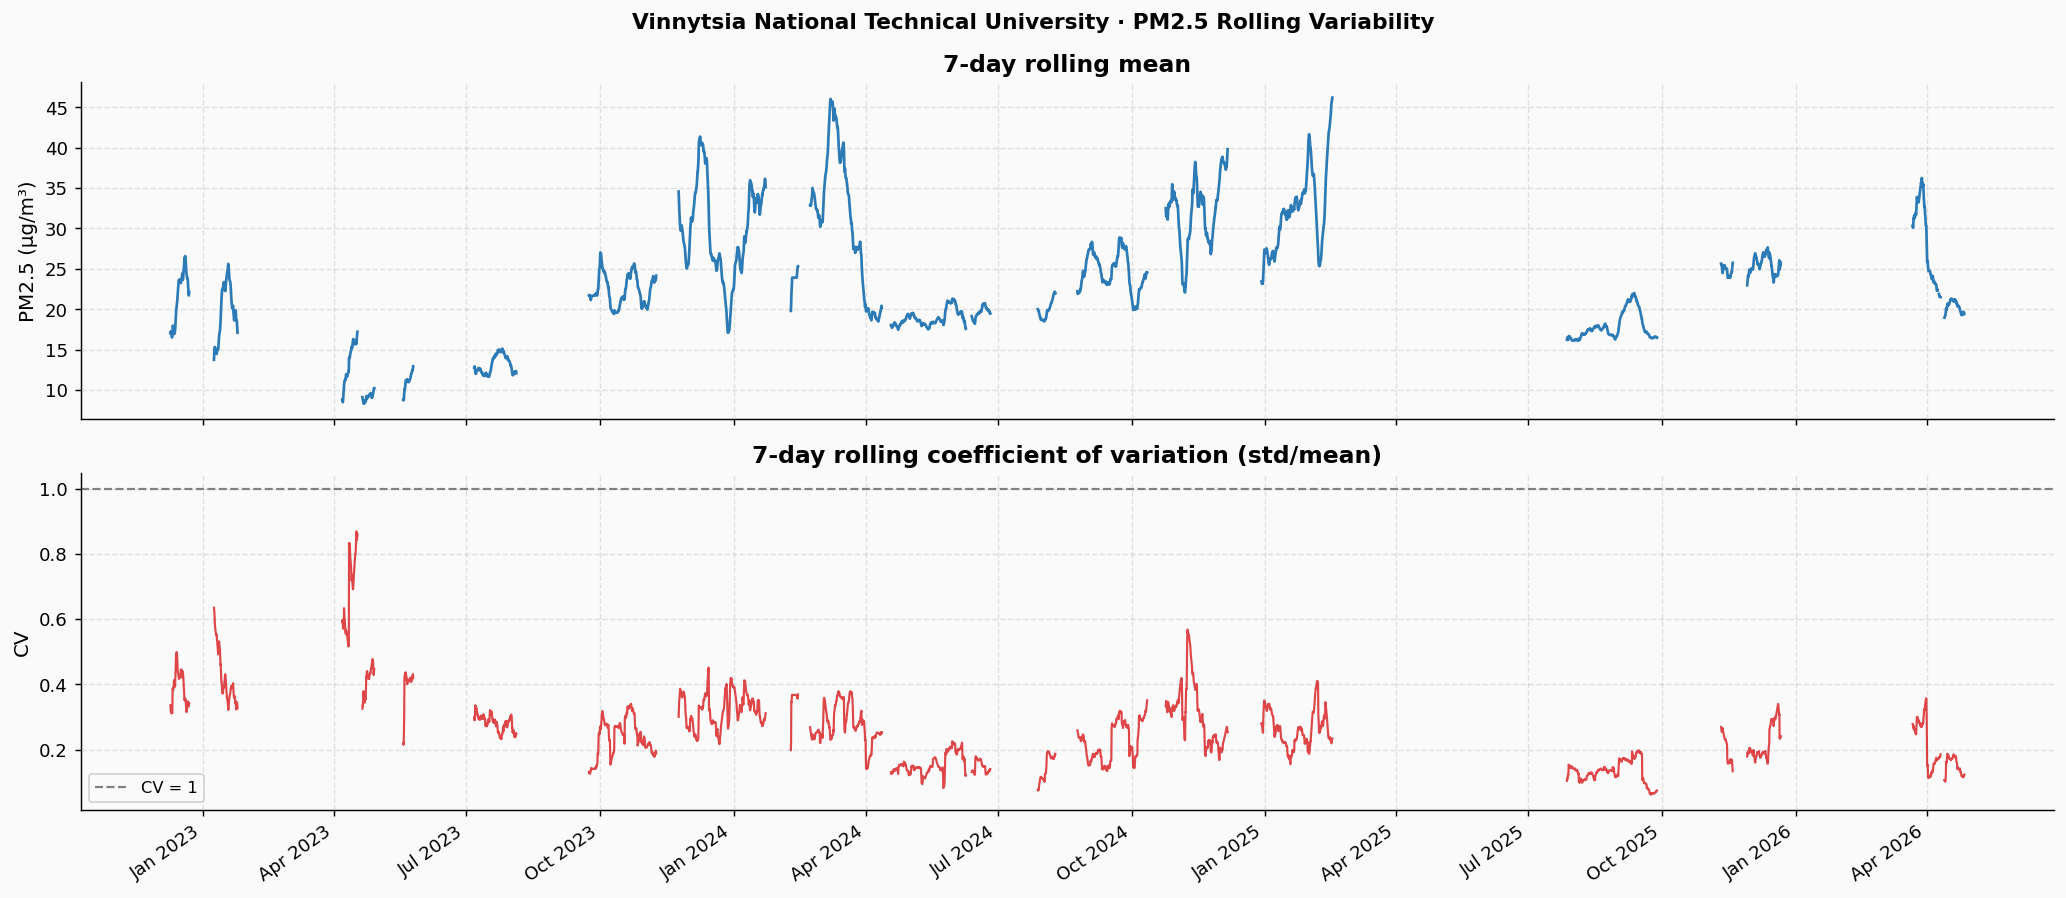

In [15]:
# ── Rolling coefficient of variation (CV) ─────────────────────────────────
roll_mean = hourly.rolling(168, min_periods=72).mean()
roll_std  = hourly.rolling(168, min_periods=72).std()
roll_cv   = (roll_std / roll_mean).replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
axes[0].plot(roll_mean.index, roll_mean, color=PALETTE['primary'], lw=1.5)
axes[0].set_title('7-day rolling mean')
axes[0].set_ylabel(f'PM2.5 ({unit_symbol})')

axes[1].plot(roll_cv.index, roll_cv, color=PALETTE['accent'], lw=1.2, alpha=0.8)
axes[1].axhline(1.0, color='grey', lw=1.2, ls='--', label='CV = 1')
axes[1].set_title('7-day rolling coefficient of variation (std/mean)')
axes[1].set_ylabel('CV')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=35, ha='right')
fig.suptitle(f'{station_name} · PM2.5 Rolling Variability', fontweight='bold')
plt.tight_layout()
plt.show()

## 7 · Seasonal & calendar patterns

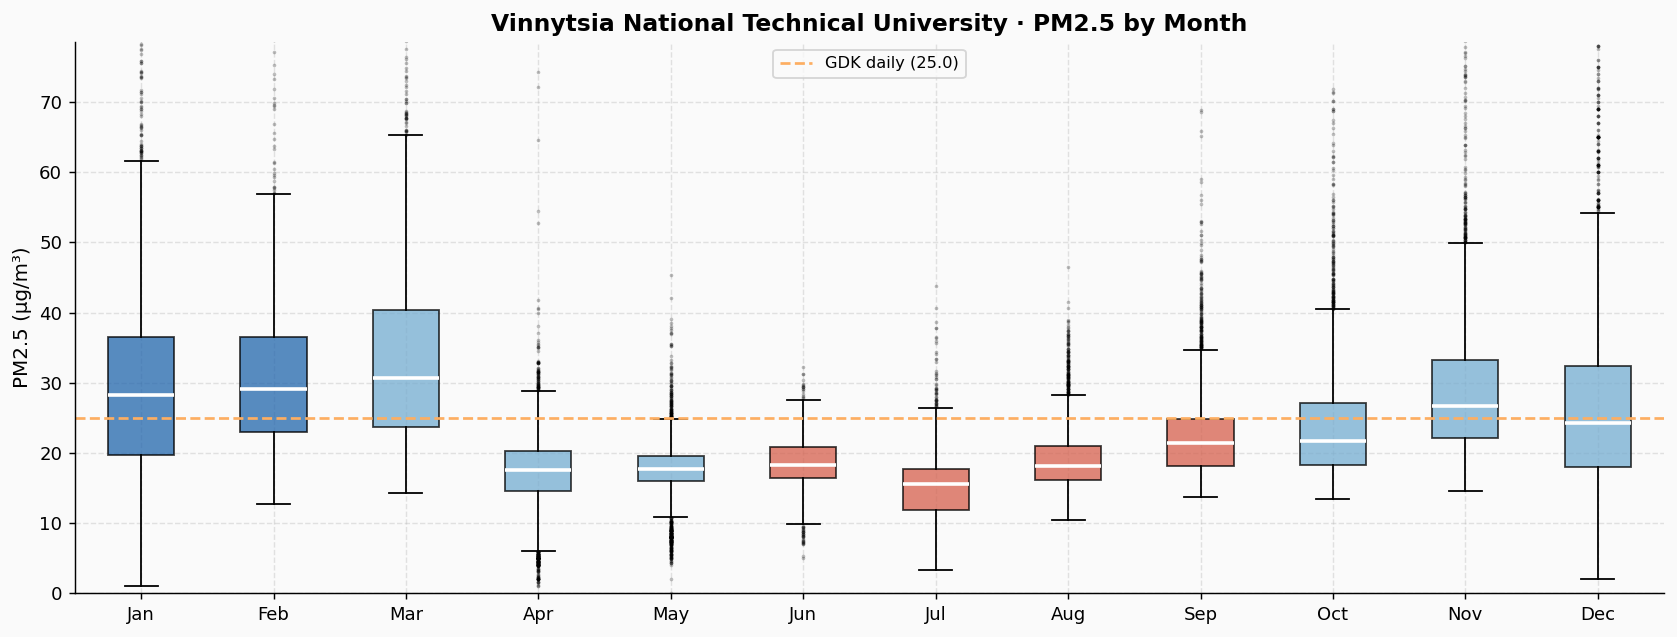

In [16]:
# ── Month-of-year box-plots ────────────────────────────────────────────────
clean = df[['pm25']].copy()
clean = clean[(clean['pm25'] >= physical_min) & (clean['pm25'] <= physical_max)]
clean['month'] = clean.index.month
clean['hour']  = clean.index.hour
clean['dow']   = clean.index.dayofweek  # 0=Mon

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_data = [clean.loc[clean['month'] == m, 'pm25'].dropna().values for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(13, 5))
bp = ax.boxplot(
    monthly_data, labels=MONTH_LABELS,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.25),
    showfliers=True,
)
winter_color = '#2166AC'
summer_color = '#D6604D'
season_colors = [winter_color]*2 + ['#74ADD1']*3 + [summer_color]*4 + ['#74ADD1']*3
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

if gdk_daily:
    ax.axhline(gdk_daily, color=PALETTE['warn'], lw=1.5, ls='--', label=f'GDK daily ({gdk_daily})')

ax.set_title(f'{station_name} · PM2.5 by Month')
ax.set_ylabel(f'PM2.5 ({unit_symbol})')
ax.set_ylim(bottom=0, top=min(physical_max, clean['pm25'].quantile(0.995)*1.1))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

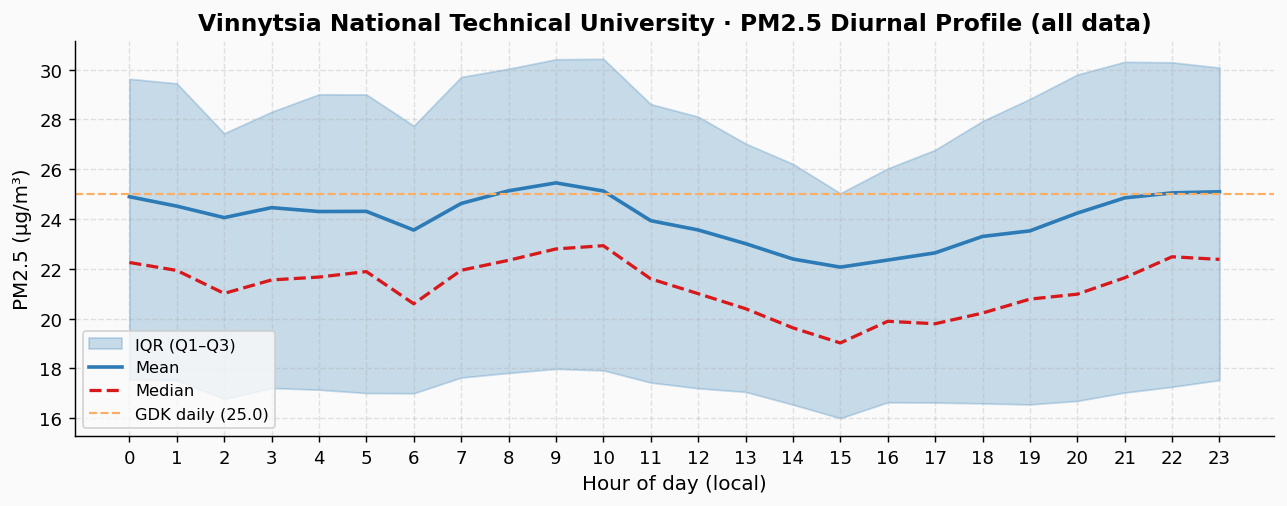

In [17]:
# ── Diurnal profile (hour of day) ─────────────────────────────────────────
hourly_profile = (
    clean.groupby('hour')['pm25']
    .agg(['mean', 'median',
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75)])
    .rename(columns={'<lambda_0>': 'q25', '<lambda_1>': 'q75'})
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(hourly_profile.index, hourly_profile['q25'], hourly_profile['q75'],
                alpha=0.25, color=PALETTE['primary'], label='IQR (Q1–Q3)')
ax.plot(hourly_profile.index, hourly_profile['mean'],   color=PALETTE['primary'], lw=2,   label='Mean')
ax.plot(hourly_profile.index, hourly_profile['median'], color=PALETTE['accent'],  lw=1.8, ls='--', label='Median')
if gdk_daily:
    ax.axhline(gdk_daily, color=PALETTE['warn'], lw=1.2, ls='--', label=f'GDK daily ({gdk_daily})')
ax.set_xticks(range(0, 24))
ax.set_xlabel('Hour of day (local)')
ax.set_ylabel(f'PM2.5 ({unit_symbol})')
ax.set_title(f'{station_name} · PM2.5 Diurnal Profile (all data)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

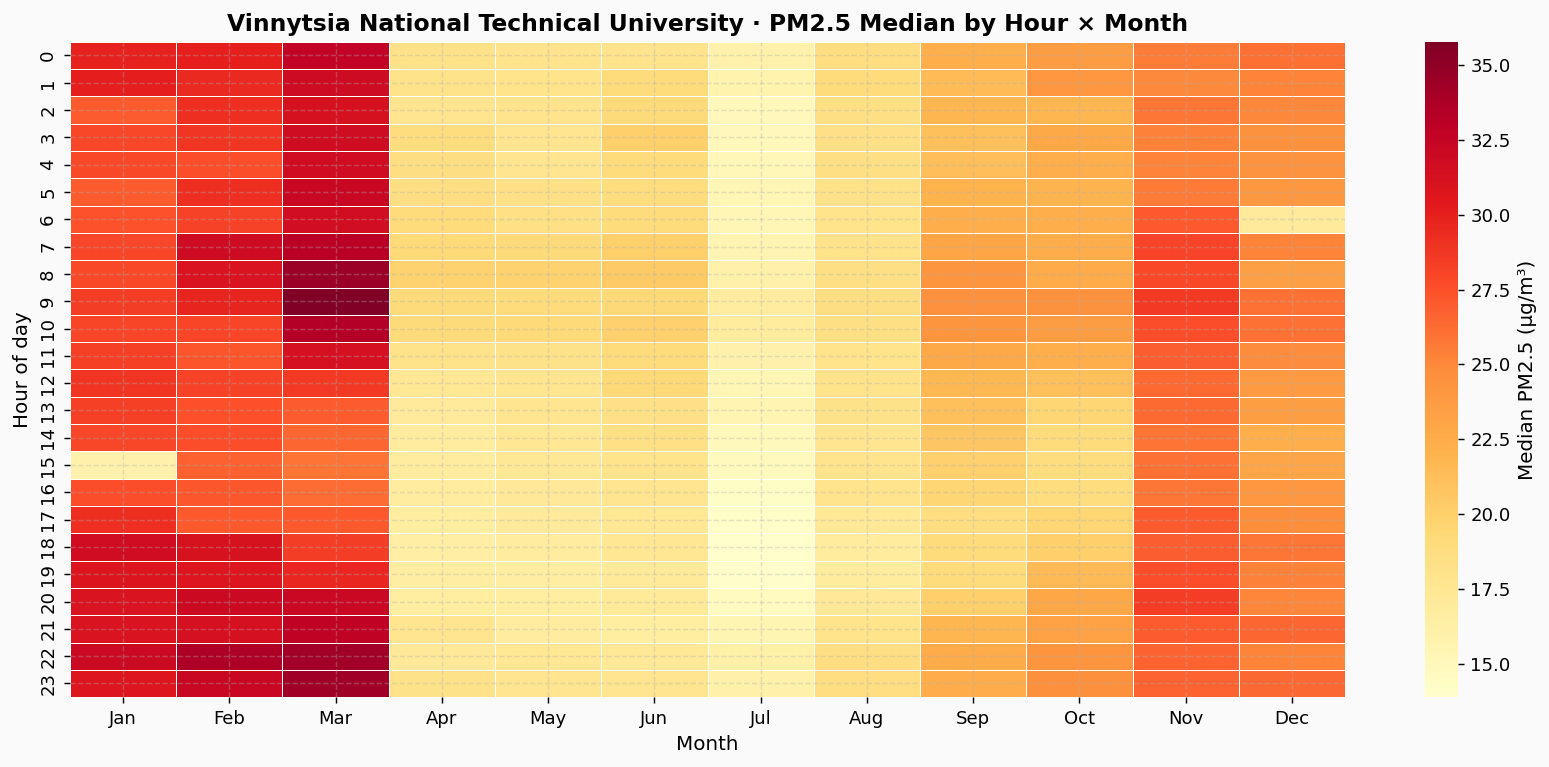

In [18]:
# ── Hour × Month heatmap of median PM2.5 ──────────────────────────────────
heatmap_data = clean.groupby(['hour', 'month'])['pm25'].median().unstack('month')
heatmap_data.columns = MONTH_LABELS

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    heatmap_data, ax=ax,
    cmap='YlOrRd', linewidths=0.5,
    cbar_kws={'label': f'Median PM2.5 ({unit_symbol})'}
)
ax.set_title(f'{station_name} · PM2.5 Median by Hour × Month')
ax.set_xlabel('Month')
ax.set_ylabel('Hour of day')
plt.tight_layout()
plt.show()

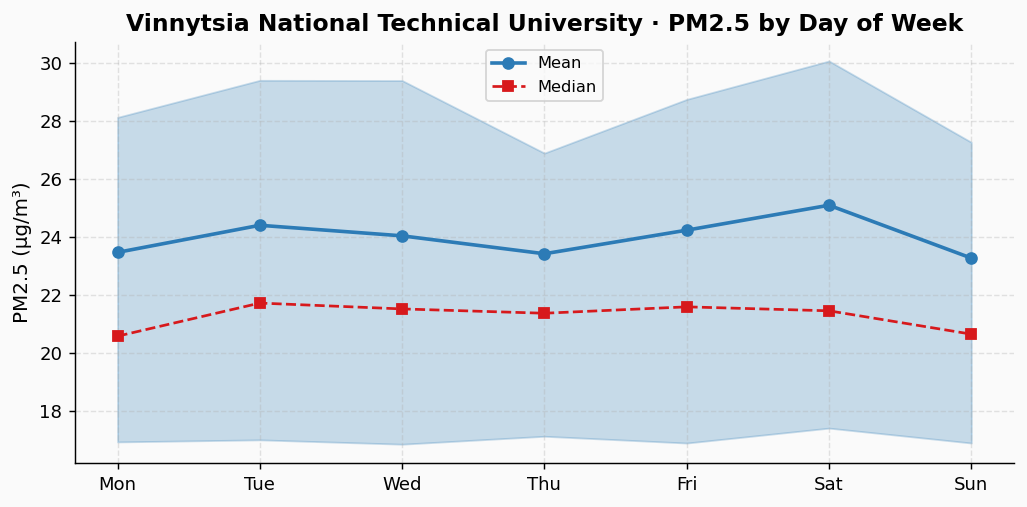

In [19]:
# ── Day-of-week profile ────────────────────────────────────────────────────
DOW_LABELS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_profile = (
    clean.groupby('dow')['pm25']
    .agg(['mean','median',
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75)])
    .rename(columns={'<lambda_0>': 'q25', '<lambda_1>': 'q75'})
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(dow_profile.index, dow_profile['q25'], dow_profile['q75'],
                alpha=0.25, color=PALETTE['primary'])
ax.plot(dow_profile.index, dow_profile['mean'],   'o-', color=PALETTE['primary'], lw=2, label='Mean')
ax.plot(dow_profile.index, dow_profile['median'], 's--', color=PALETTE['accent'], lw=1.5, label='Median')
ax.set_xticks(range(7))
ax.set_xticklabels(DOW_LABELS)
ax.set_ylabel(f'PM2.5 ({unit_symbol})')
ax.set_title(f'{station_name} · PM2.5 by Day of Week')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8 · Quality ratio & data flags

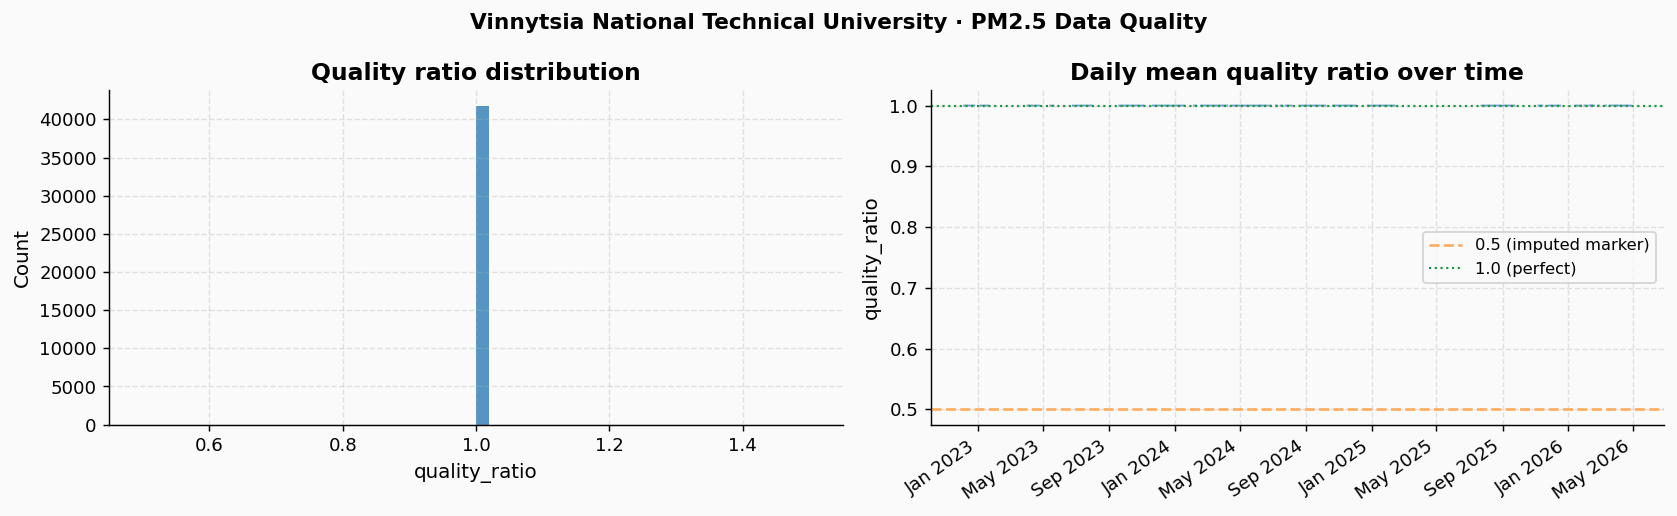

quality_ratio value counts (rounded to 1 dp):
quality_ratio
1.0    41723
Name: count, dtype: int64


In [20]:
# ── Quality ratio distribution ─────────────────────────────────────────────
qr = df['quality_ratio'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(qr, bins=50, color=PALETTE['primary'], edgecolor='none', alpha=0.8)
axes[0].set_title('Quality ratio distribution')
axes[0].set_xlabel('quality_ratio')
axes[0].set_ylabel('Count')

# ── quality_ratio over time ────────────────────────────────────────────────
daily_qr = df['quality_ratio'].resample('D').mean()
axes[1].plot(daily_qr.index, daily_qr, color=PALETTE['primary'], lw=1.0, alpha=0.7)
axes[1].axhline(0.5, color=PALETTE['warn'],  lw=1.5, ls='--', label='0.5 (imputed marker)')
axes[1].axhline(1.0, color=PALETTE['ok'],    lw=1.2, ls=':',  label='1.0 (perfect)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=35, ha='right')
axes[1].set_title('Daily mean quality ratio over time')
axes[1].set_ylabel('quality_ratio')
axes[1].legend(fontsize=9)

fig.suptitle(f'{station_name} · PM2.5 Data Quality', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'quality_ratio value counts (rounded to 1 dp):')
print(qr.round(1).value_counts().sort_index())

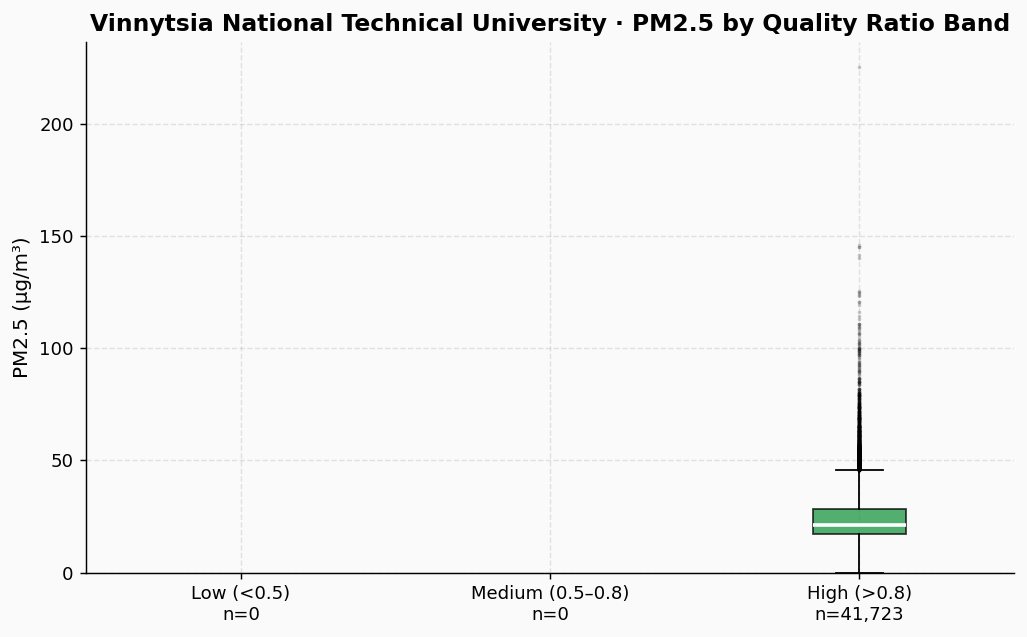

In [21]:
# ── PM2.5 value stratified by quality_ratio bands ─────────────────────────
bands = pd.cut(df['quality_ratio'], bins=[0, 0.49, 0.79, 1.01],
               labels=['Low (<0.5)', 'Medium (0.5–0.8)', 'High (>0.8)'],
               include_lowest=True)
band_data = [df.loc[bands == b, 'pm25'].dropna().values for b in bands.cat.categories]
band_labels = [f"{b}\nn={len(d):,}" for b, d in zip(bands.cat.categories, band_data)]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    band_data, labels=band_labels,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.2),
)
for patch, color in zip(bp['boxes'], [PALETTE['accent'], PALETTE['warn'], PALETTE['ok']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title(f'{station_name} · PM2.5 by Quality Ratio Band')
ax.set_ylabel(f'PM2.5 ({unit_symbol})')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 9 · Pollution-level distribution

## 10 · Anomaly / out-of-bounds audit

In [23]:
# ── Classify every reading ─────────────────────────────────────────────────
valid_df = df[['pm25','quality_ratio']].copy()
valid_df['status'] = 'valid'
valid_df.loc[valid_df['pm25'].isna(), 'status'] = 'null'
valid_df.loc[valid_df['pm25'] < physical_min, 'status'] = 'below_min'
valid_df.loc[valid_df['pm25'] > physical_max, 'status'] = 'above_max'

status_counts = valid_df['status'].value_counts()
print('Reading classification:')
print(status_counts.to_string())

# ── IQR-based outlier within valid range ──────────────────────────────────
in_range_vals = valid_df.loc[valid_df['status'] == 'valid', 'pm25']
Q1, Q3 = in_range_vals.quantile(0.25), in_range_vals.quantile(0.75)
IQR = Q3 - Q1
iqr_upper = Q3 + 3 * IQR
n_iqr_outliers = (in_range_vals > iqr_upper).sum()
print(f'\nIQR 3× upper fence: {iqr_upper:.2f} {unit_symbol}')
print(f'Values above IQR fence (still in physical range): {n_iqr_outliers:,}')

Reading classification:
status
valid    41723

IQR 3× upper fence: 63.18 µg/m³
Values above IQR fence (still in physical range): 390


In [27]:
# ── Out-of-bounds readings over time ──────────────────────────────────────
oob = valid_df[valid_df['status'].isin(['below_min','above_max'])]

if len(oob) == 0:
    print('No out-of-bounds values found — skipping chart.')
else:
    oob_daily = (
        oob.groupby([oob.index.floor('D'), 'status'])
        .size()
        .unstack('status', fill_value=0)
    )
    fig, ax = plt.subplots(figsize=(15, 4))
    for col, color in zip(oob_daily.columns, [PALETTE['primary'], PALETTE['accent']]):
        ax.bar(oob_daily.index, oob_daily[col], label=col, color=color, alpha=0.75)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
    ax.set_title(f'{station_name} · PM2.5 Out-of-Bounds Readings per Day')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

No out-of-bounds values found — skipping chart.


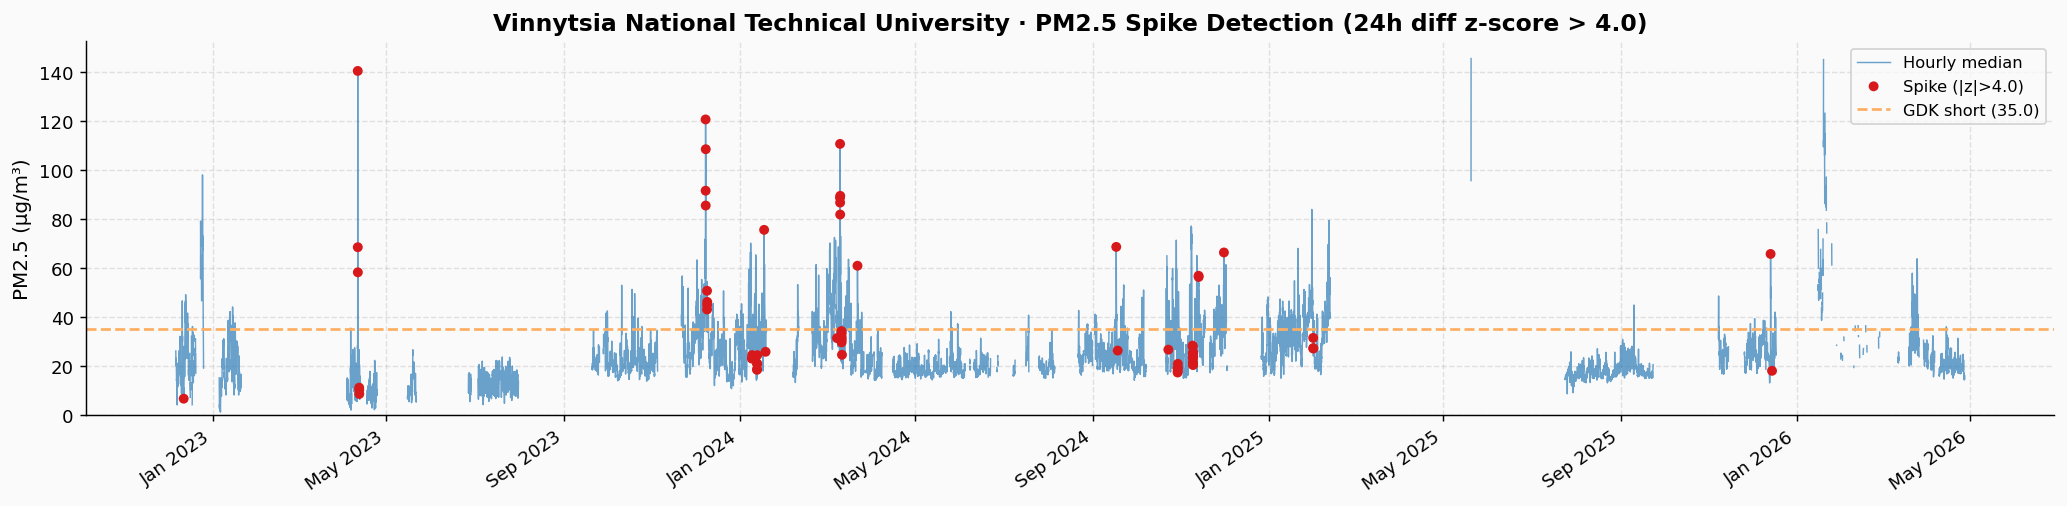

Spike events detected: 66


In [25]:
# ── Spike detection: z-score on 24h differenced series ────────────────────
hourly_vals = df['pm25'].resample('h').median()
diff24 = hourly_vals.diff(24)  # change from same hour yesterday

z = (diff24 - diff24.mean()) / diff24.std()
spike_threshold = 4.0
spikes = diff24[z.abs() > spike_threshold]

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(hourly_vals.index, hourly_vals, color=PALETTE['primary'], lw=0.8, alpha=0.7, label='Hourly median')
ax.scatter(spikes.index, hourly_vals.loc[spikes.index], color=PALETTE['accent'],
           s=30, zorder=5, label=f'Spike (|z|>{spike_threshold})', edgecolors='none')
if gdk_short:
    ax.axhline(gdk_short, color=PALETTE['warn'], lw=1.5, ls='--', label=f'GDK short ({gdk_short})')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
ax.set_ylim(bottom=0)
ax.set_title(f'{station_name} · PM2.5 Spike Detection (24h diff z-score > {spike_threshold})')
ax.set_ylabel(f'PM2.5 ({unit_symbol})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'Spike events detected: {len(spikes):,}')

## 11 · Correlation with other parameters at VNTU

In [26]:
# ── Fetch all parameters at this station ──────────────────────────────────
OTHER_PARAMS_QUERY = text("""
    SELECT
        fm.measurement_timestamp,
        dp.parameter_code,
        fm.value
    FROM   fact_measurements fm
    JOIN   dim_parameters dp ON dp.parameter_key = fm.parameter_key
    WHERE  fm.station_key  = :sk
      AND  dp.is_current   = 1
      AND  fm.value        IS NOT NULL
      AND  dp.parameter_code NOT IN :pm25_codes
    ORDER  BY fm.measurement_timestamp
""")

with engine.connect() as c:
    other_df = pd.read_sql(
        OTHER_PARAMS_QUERY,
        c,
        params={'sk': station_key, 'pm25_codes': PM25_CODES},
        parse_dates=['measurement_timestamp']
    )

print(f'Other parameters at station: {other_df["parameter_code"].unique()}')
print(f'Rows: {len(other_df):,}')

Other parameters at station: <ArrowStringArray>
['Temperature',         'NO2',        'HCHO',         'CO2',          'CO',
    'Pressure',    'Humidity',        'PM10',       'PM1.0',          'O3',
         'VOC']
Length: 11, dtype: str
Rows: 469,163


In [28]:
# ── Build hourly pivot table ───────────────────────────────────────────────
other_pivot = (
    other_df
    .set_index('measurement_timestamp')
    .pivot_table(index='measurement_timestamp', columns='parameter_code', values='value', aggfunc='median')
    .resample('h')
    .median()
)

pm25_hourly = df['pm25'].resample('h').median().rename('PM2.5')
combined = pd.concat([pm25_hourly, other_pivot], axis=1)

print(f'Combined shape: {combined.shape}')
combined.head()

Combined shape: (29703, 12)


,PM2.5,CO,CO2,HCHO,Humidity,NO2,O3,PM1.0,PM10,Pressure,Temperature,VOC
2022-12-06 10:00:00,26.0,0.5,402.0,0.013,80.8550,0.120,0.020,22.0,29.0,99210.4,-3.850,NaN
2022-12-06 11:00:00,23.0,0.5,402.0,0.013,80.5175,0.120,0.020,18.0,25.0,99146.1,-3.475,NaN
2022-12-06 12:00:00,21.0,0.5,402.0,0.013,80.4325,0.120,0.020,17.0,23.5,99059.4,-3.255,NaN
2022-12-06 13:00:00,20.0,0.5,402.0,0.013,80.4675,0.119,0.020,17.0,23.0,99016.8,-3.145,NaN
2022-12-06 14:00:00,22.5,0.5,402.0,0.013,80.9725,0.118,0.025,17.5,24.5,98977.4,-3.275,NaN


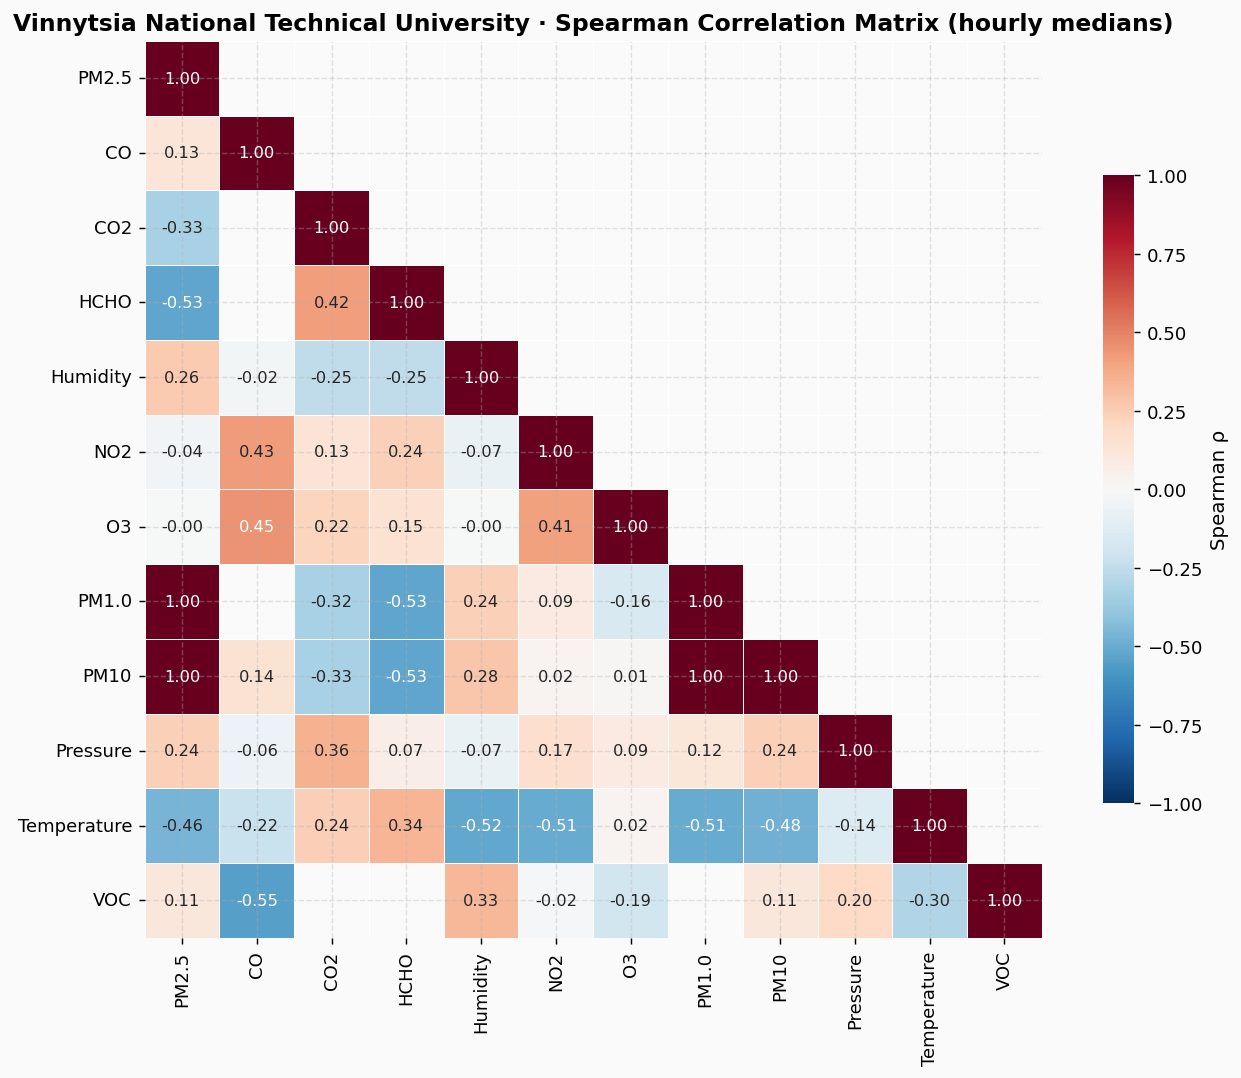

In [29]:
# ── Correlation heatmap ────────────────────────────────────────────────────
corr = combined.corr(method='spearman')

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(max(8, len(corr)*0.8 + 1), max(6, len(corr)*0.7)))
sns.heatmap(
    corr, ax=ax, mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    square=True, linewidths=0.5,
    cbar_kws={'label': "Spearman ρ", 'shrink': 0.7}
)
ax.set_title(f'{station_name} · Spearman Correlation Matrix (hourly medians)')
plt.tight_layout()
plt.show()

Top 4 correlated parameters with PM2.5: ['PM1.0', 'PM10', 'HCHO', 'Temperature']


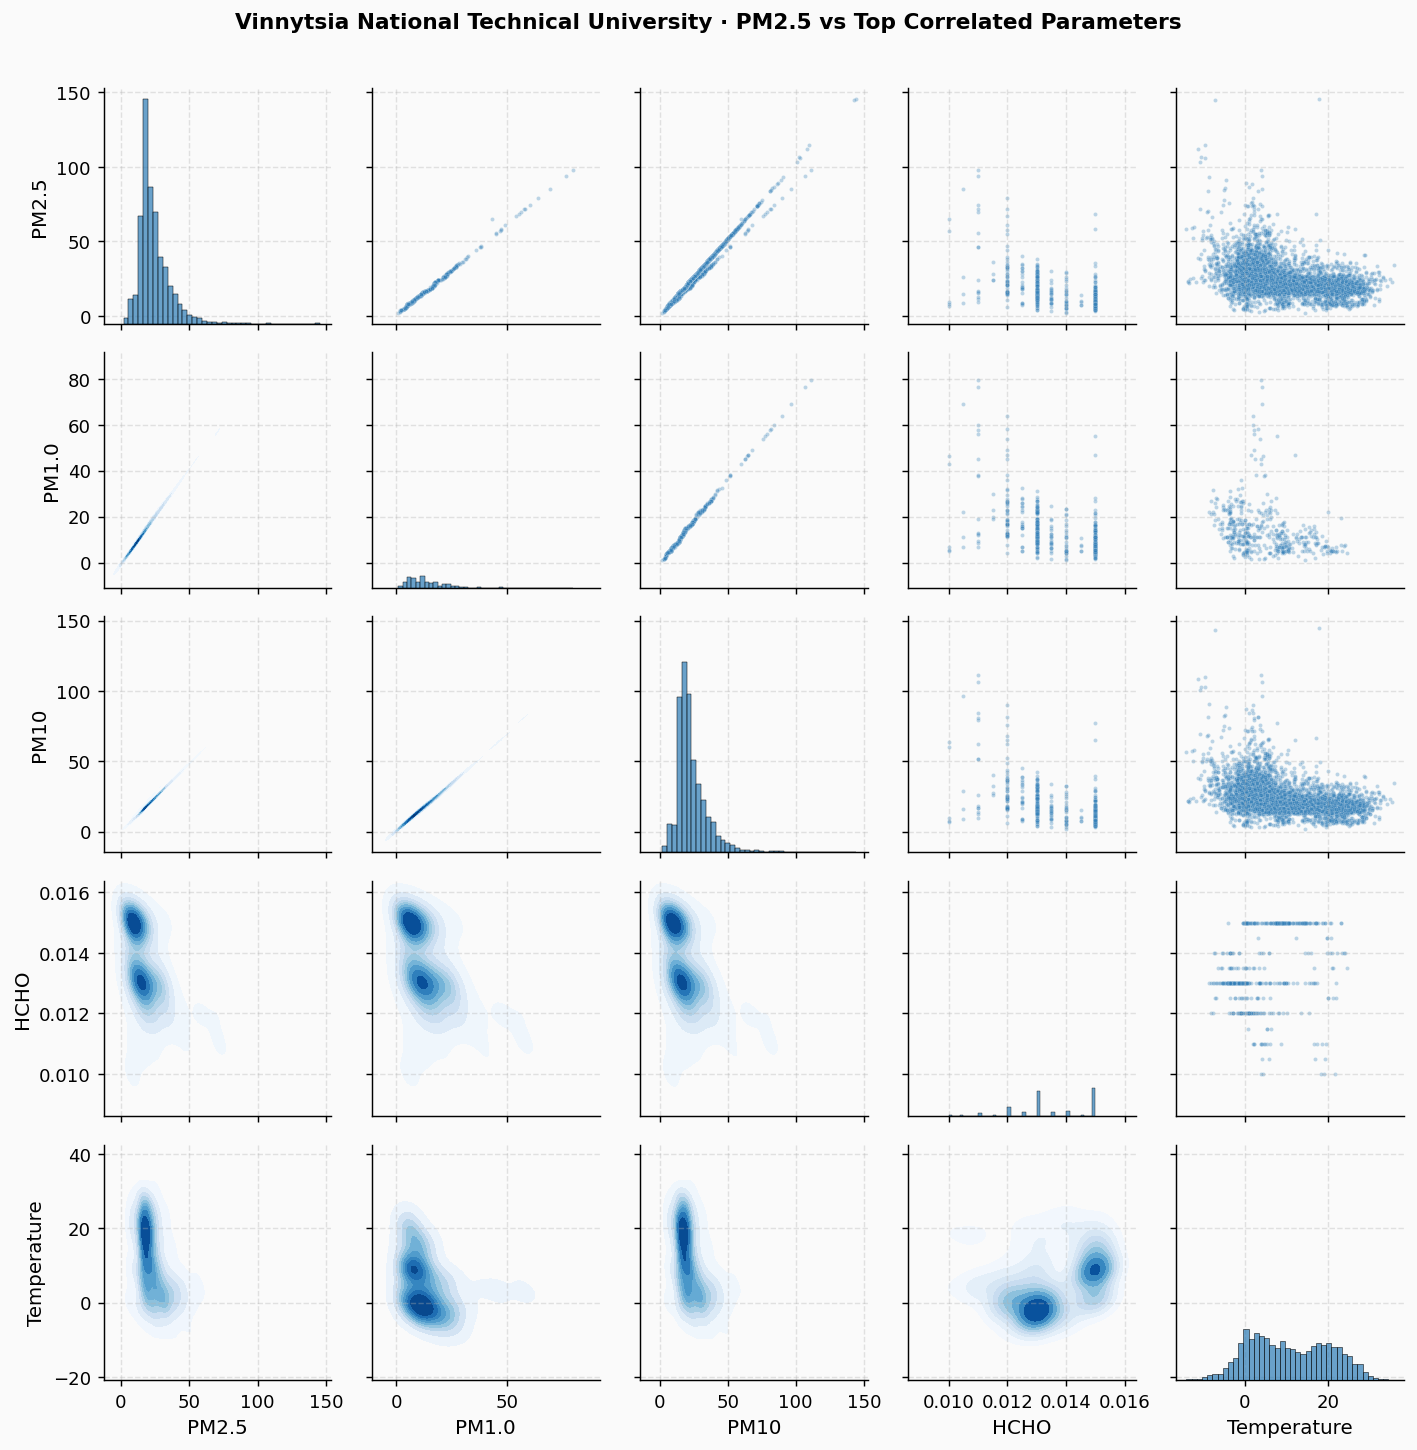

In [30]:
# ── Scatter matrix for PM2.5 vs top correlated parameters ─────────────────
pm25_corrs = corr['PM2.5'].drop('PM2.5').abs().sort_values(ascending=False)
top_params = pm25_corrs.head(4).index.tolist()
print('Top 4 correlated parameters with PM2.5:', top_params)

if top_params:
    scatter_cols = ['PM2.5'] + top_params
    scatter_data = combined[scatter_cols].dropna(how='all').sample(min(5000, len(combined)), random_state=42)

    g = sns.PairGrid(scatter_data, vars=scatter_cols, height=2.2)
    g.map_upper(sns.scatterplot, s=5, alpha=0.3, color=PALETTE['primary'], rasterized=True)
    g.map_lower(sns.kdeplot, fill=True, cmap='Blues')
    g.map_diag(sns.histplot, bins=40, color=PALETTE['primary'], alpha=0.7)
    g.figure.suptitle(f'{station_name} · PM2.5 vs Top Correlated Parameters', y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 12 · Key findings

In [31]:
# ── Summary dashboard ──────────────────────────────────────────────────────
inrange = df.loc[df['pm25'].between(physical_min, physical_max), 'pm25']

exceedances_daily = None
if gdk_daily:
    daily_mean = inrange.resample('D').mean()
    exceedances_daily = (daily_mean > gdk_daily).sum()

print('═' * 55)
print(f'  STATION : {station_name} (ID {STATION_ID})')
print(f'  PARAM   : PM2.5 ({unit_symbol})')
print('═' * 55)
print(f'  Date range       : {df.index.min().date()} → {df.index.max().date()}')
print(f'  Total readings   : {len(df):,}')
print(f'  In-range (clean) : {len(inrange):,}  ({len(inrange)/len(df)*100:.1f}%)')
print(f'  Mean             : {inrange.mean():.2f}')
print(f'  Median           : {inrange.median():.2f}')
print(f'  Std dev          : {inrange.std():.2f}')
print(f'  p95              : {inrange.quantile(0.95):.2f}')
print(f'  p99              : {inrange.quantile(0.99):.2f}')
print(f'  Max              : {inrange.max():.2f}')
if gdk_daily:
    print(f'  GDK daily {gdk_daily}       : exceeded on {exceedances_daily} days')
if gdk_short:
    exc = (inrange > gdk_short).sum()
    print(f'  GDK short-term {gdk_short}  : exceeded {exc:,} readings ({exc/len(inrange)*100:.1f}%)')
print('═' * 55)

═══════════════════════════════════════════════════════
  STATION : Vinnytsia National Technical University (ID 1315)
  PARAM   : PM2.5 (µg/m³)
═══════════════════════════════════════════════════════
  Date range       : 2022-12-06 → 2026-04-27
  Total readings   : 41,723
  In-range (clean) : 41,723  (100.0%)
  Mean             : 24.00
  Median           : 21.24
  Std dev          : 11.22
  p95              : 44.58
  p99              : 62.64
  Max              : 225.48
  GDK daily 25.0       : exceeded on 239 days
  GDK short-term 35.0  : exceeded 5,673 readings (13.6%)
═══════════════════════════════════════════════════════
